In [60]:
# импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [61]:
#загрузка данных
wine = load_wine(as_frame=True)
data = wine.data
target = wine.target
data['target'] = target

In [62]:
#вывод датасета
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [63]:
print(f"Размер датасета: {data.shape[0]} объектов, {data.shape[1]} признаков")

Размер датасета: 178 объектов, 14 признаков


In [64]:
#проверка на наличие пропусков
data.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

In [65]:
#выведем статистические характеристики
data.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [66]:
# создаем датасет из 7 признаков
d1 = data[['alcohol', 'malic_acid', 'ash','magnesium','total_phenols', 'color_intensity', 'proline']]
print("размер d1:", d1.shape)

размер d1: (178, 7)


In [67]:
# масштабирование
scaler = StandardScaler()
d1 = scaler.fit_transform(d1)

In [68]:
# снижение размерности (до 2)

In [69]:
# метод главных компонент
pca = PCA(n_components=2)
d2 = pca.fit_transform(d1)
print('Доля объясненной дисперсии: {}, сумма={}'.format(pca.explained_variance_ratio_, np.sum(pca.explained_variance_ratio_)))
d2[:10]

Доля объясненной дисперсии: [0.36601828 0.22357006], сумма=0.5895883362542343


array([[ 2.45140365, -0.68309669],
       [ 0.489887  , -1.09519756],
       [ 1.55985558, -0.25766748],
       [ 3.83849142, -1.09018759],
       [ 1.29091457,  0.02291228],
       [ 3.1344976 , -0.99265425],
       [ 1.9259527 , -0.42280197],
       [ 2.56044412, -0.37658197],
       [ 1.67037727, -0.82626307],
       [ 1.61705442, -0.82622215]])

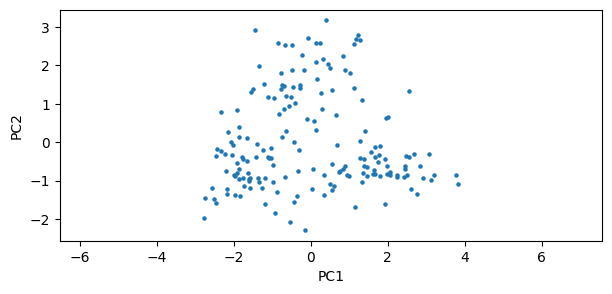

In [70]:
# построение графика
plt.figure(figsize=(7,3))
plt.scatter(d2[:, 0], d2[:, 1], s=5)
plt.axis('equal')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [71]:
# метод t-SNE
tsne = TSNE(n_components=2)
d3 = tsne.fit_transform(d1)
d3[:10]

array([[ 8.663217  ,  1.9923154 ],
       [ 5.962535  , -4.4456496 ],
       [ 7.118854  , -0.66704744],
       [11.8090725 , -0.42757955],
       [ 4.251872  ,  1.155992  ],
       [10.855125  , -0.79022723],
       [ 8.516217  , -2.8151598 ],
       [ 9.6407995 ,  1.5021917 ],
       [ 9.274361  , -4.121423  ],
       [ 8.560357  , -4.0724483 ]], dtype=float32)

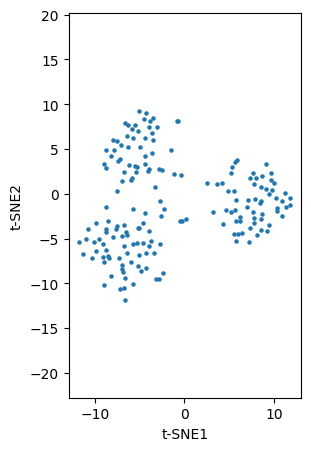

In [72]:
# построение графика
plt.figure(figsize=(3,5))
plt.scatter(d3[:, 0], d3[:, 1], s=5)
plt.axis('equal')
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.show()

In [73]:
cluster_datasets = [d1, d2, d3]

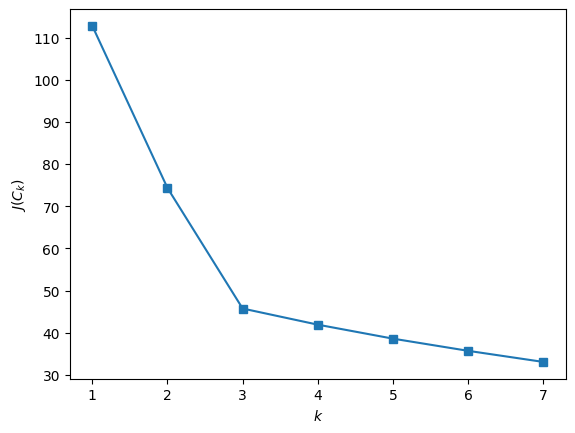

In [74]:
# кластеризация методом k-средних

# метод локтя для подбора гиперпараметра количества кластеров
inertia = []
TEMP_X = cluster_datasets[2]
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=1).fit(TEMP_X)
    inertia.append(np.sqrt(kmeans.inertia_))
plt.plot(range(1, 8), inertia, marker='s');
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$');

In [75]:
# берем n = 3 кластера
def do_clustering(cluster_datasets, method):
    cluster_results = []
    for X in cluster_datasets:
        temp_cluster = method.fit_predict(X)
        cluster_results.append(temp_cluster)
    return cluster_results
from sklearn.cluster import KMeans, MiniBatchKMeans
%time result_KMeans_3 = do_clustering(cluster_datasets, KMeans(n_clusters=3))

CPU times: user 7.34 ms, sys: 8.47 ms, total: 15.8 ms
Wall time: 3.2 ms


In [76]:
# Визуализация результатов кластерного анализа
x = 0
def visualize_clusters(X, cluster_results):
    global x
    if x == 3:
        x = 0
    plt.figure(figsize=(3,5))
    plt.scatter(X[:, 0], X[:, 1], s=5, c=cluster_results[x])
    plt.xticks(())
    plt.yticks(())
    plt.show()
    x += 1

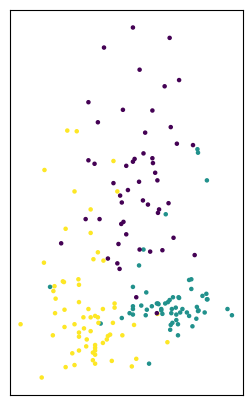

1


In [77]:
visualize_clusters(np.array(d1), result_KMeans_3)
print(x)

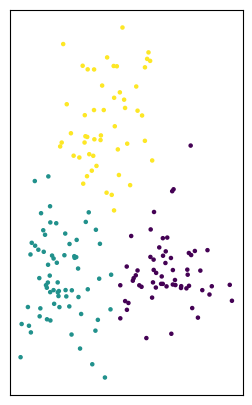

2


In [78]:
visualize_clusters(np.array(d2), result_KMeans_3)
print(x)

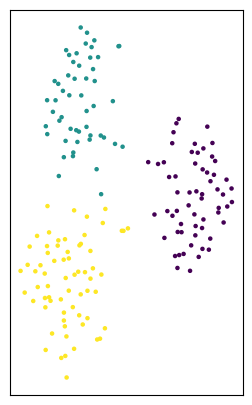

3


In [79]:
visualize_clusters(np.array(d3), result_KMeans_3)
print(x)

In [80]:
# Вычисление метрик кластеризации для d1, d2, d3
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score, 
    adjusted_mutual_info_score, 
    homogeneity_completeness_v_measure, 
    silhouette_score
)

def claster_metrics(method, cluster_datasets, cluster_true_y, datasets_names):

    ari = []
    ami = []
    hl = []
    cl = []
    vl = []
    sl = []
    
    for X, true_y in zip(cluster_datasets, cluster_true_y):
        temp_cluster = method.fit_predict(X)
        
        # Считаем внешние метрики (сравнение с реальными классами вина)
        ari.append(adjusted_rand_score(true_y, temp_cluster))
        ami.append(adjusted_mutual_info_score(true_y, temp_cluster))
        h, c, v = homogeneity_completeness_v_measure(true_y, temp_cluster)
        hl.append(h)
        cl.append(c)
        vl.append(v)
    
        # Считаем силуэтный коэффициент (внутреннее качество геометрии)
        try:
            sscore = silhouette_score(X, temp_cluster)
        except:
            sscore = None
            
        sl.append(sscore)
    
    actual_length = len(cluster_datasets)
    
    result = pd.DataFrame({
        'Datasets': datasets_names[0:actual_length], 
        'ARI': ari, 
        'AMI': ami, 
        'Homogeneity': hl, 
        'Completeness': cl, 
        'V-measure': vl, 
        'Silhouette': sl
    })
    return result

In [81]:
true_labels = load_wine().target

# 2. Собираем списки для функции
my_datasets = [d1, d2, d3]
my_true_y = [true_labels, true_labels, true_labels] # Повторяем для каждого пространства
my_names = ['Original', 'PCA', 't-SNE']

# 3. Вызываем функцию для KMeans
from sklearn.cluster import KMeans
kmeans_table = claster_metrics(KMeans(n_clusters=3, random_state=42), my_datasets, my_true_y, my_names)

print(kmeans_table)

   Datasets       ARI       AMI  Homogeneity  Completeness  V-measure  \
0  Original  0.731543  0.658945     0.664642      0.660410   0.662519   
1       PCA  0.747271  0.672339     0.677774      0.673785   0.675774   
2     t-SNE  0.806762  0.754594     0.759906      0.754442   0.757164   

   Silhouette  
0    0.298052  
1    0.545076  
2    0.617508  


CPU times: user 27.6 ms, sys: 23.1 ms, total: 50.7 ms
Wall time: 23.4 ms


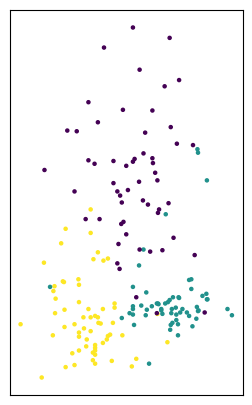

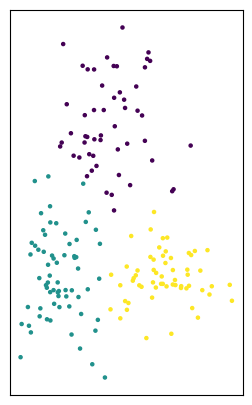

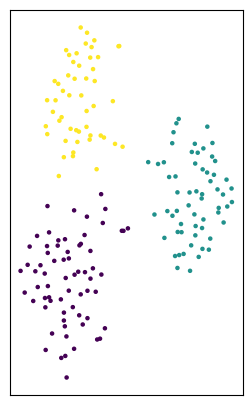

In [82]:
# кластеризация методом Birch
from sklearn.cluster import Birch
%time result_Birch = do_clustering(cluster_datasets, Birch())
for i in range(3):
    # Передаем i-й датасет и весь список результатов
    visualize_clusters(cluster_datasets[i], result_Birch)

In [83]:
birch_table = claster_metrics(
    Birch(n_clusters=3), 
    my_datasets, 
    my_true_y, 
    my_names
)
# Выводим таблицу на экран
display(birch_table)

,Datasets,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Original,0.693985,0.654686,0.661838,0.654793,0.658296,0.284651
1,PCA,0.749578,0.698657,0.704581,0.699065,0.701812,0.530101
2,t-SNE,0.822407,0.770741,0.775433,0.770869,0.773144,0.617882


CPU times: user 932 ms, sys: 674 ms, total: 1.61 s
Wall time: 457 ms


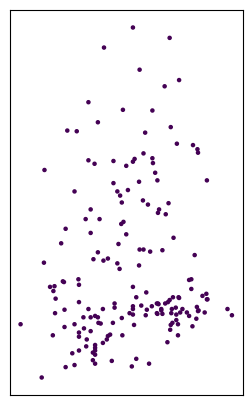

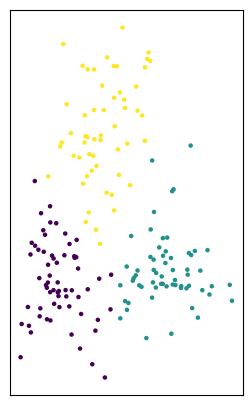

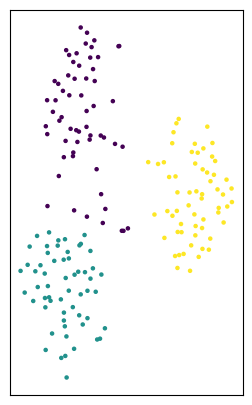

In [84]:
# кластеризация методом MeanShift
from sklearn.cluster import MeanShift
%time result_MeanShift = do_clustering(cluster_datasets, MeanShift())
for i in range(3):
    # Передаем i-й датасет и весь список результатов
    visualize_clusters(cluster_datasets[i], result_MeanShift)

In [85]:
meanshift_table = claster_metrics(
    MeanShift(), 
    my_datasets, 
    my_true_y, 
    my_names
)
# Выводим таблицу 
display(meanshift_table) 

,Datasets,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,Original,0.000000,0.000000,0.000000,1.000000,0.000000,NaN
1,PCA,0.717875,0.652416,0.659434,0.652703,0.656051,0.532993
2,t-SNE,0.718134,0.692098,0.699301,0.691377,0.695316,0.595394


In [ ]:
# В исходном пространстве лучшим оказался K-Means (ARI = 0.7315), так как его геометрический принцип деления на сферы устойчив
# к «проклятию размерности», полностью парализовавшему плотностной метод MeanShift. После снижения размерности до 2D лидирующие 
# позиции занял иерархический метод Birch, CF-дерево которого идеально легло на структуру данных: алгоритм показал лучший результат в 
# пространстве PCA (ARI = 0.7496)  в связке с нелинейным пространством t-SNE, достигнув рекордной
# точности (ARI = 0.8224) и максимальной четкости границ (Silhouette = 0.6179)